In [1]:
import os
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# Notebook/ -> 04_Python/ -> raiz do projeto
RAIZ = Path.cwd().parents[1]
SAIDA_IMG = RAIZ / "05_PowerBI" / "Imagens"
SAIDA_CSV = RAIZ / "05_PowerBI" / "Tabelas"
SAIDA_IMG.mkdir(parents=True, exist_ok=True)
SAIDA_CSV.mkdir(parents=True, exist_ok=True)

load_dotenv(RAIZ / ".env")
engine = create_engine(URL.create(
    "postgresql+psycopg2",
    username=os.getenv("PGUSER"), password=os.getenv("PGPASSWORD"),
    host=os.getenv("PGHOST"), port=int(os.getenv("PGPORT")),
    database=os.getenv("PGDATABASE"),
))

COLUNAS = ("id_ponto, id_trilha, tipo, declividade, solo, condicoes_trilha, "
           "sinais_erosao, obstaculos_riscos, nivel_perigo, escala_perigo")

pontos = pd.read_sql(
    " UNION ALL ".join(
        f"SELECT {COLUNAS} FROM public.pontos_trilha_{i}" for i in (1, 2, 3)),
    engine)

fotos = pd.read_sql(
    " UNION ALL ".join(
        f"SELECT id_foto, id_ponto FROM public.fotos_trilha_{i}_stg"
        for i in (1, 2, 3)),
    engine)

NOMES_TRILHA = {"T01": "Pau da Fome", "T02": "Pedra Negra",
                "T03": "Morro dos Caboclos"}
pontos["trilha"] = pontos["id_trilha"].map(NOMES_TRILHA)

print(f"Pontos: {len(pontos)}   Fotos: {len(fotos)}")
pontos.head()


Pontos: 70   Fotos: 144


,id_ponto,id_trilha,tipo,declividade,solo,condicoes_trilha,sinais_erosao,obstaculos_riscos,nivel_perigo,escala_perigo,trilha
0,T1P001,T01,Drenagem,Muito Baixa,Misto (Arenoso/argiloso),Largura pouco mens de 1 metro com degraus natu...,Desgaste do solo por fluxo de pessoas e de água,,Baixo,2,Pau da Fome
1,T1P002,T01,Erosão,Muito Baixa,Arenoso,"Largura de cerca de 1 metro, observa-se um des...",Deslizamento do lado direito da trilha,Troncos caidos,Médio,3,Pau da Fome
2,T1P003,T01,Drenagem,Baixa,Arenoso,Largura de aproximadamente 8 metros e presença...,Solo apresenta muito desnível devido a erosão ...,Risco de queda,Baixo,2,Pau da Fome
3,T1P004,T01,Declive,Muito Baixa,Arenoso,1.20 metros de largura com uma área de declive...,Solo pouco compactado e escorregadio do lado d...,Risco de queda,Baixo,2,Pau da Fome
4,T1P005,T01,Drenagem,Baixa,Arenoso,Rio com cerca de 10 metros de uma margem até a...,,Rio,Alto,4,Pau da Fome


In [2]:
for coluna in ["id_trilha", "tipo", "declividade", "solo",
               "nivel_perigo", "escala_perigo"]:
    contagem = pontos[coluna].value_counts(dropna=False)
    print(f"\n### {coluna} — {len(contagem)} valores distintos")
    for valor, n in contagem.items():
        print(f"   {n:>3}  {valor!r}")

for coluna in ["sinais_erosao", "obstaculos_riscos", "condicoes_trilha"]:
    serie = pontos[coluna].dropna()
    print(f"\n### {coluna} — {serie.nunique()} distintos em {len(serie)} "
          f"preenchidos, {serie.str.len().mean():.0f} caracteres em média")
    for texto in serie.head(3):
        print(f"   - {texto[:100]}")



### id_trilha — 3 valores distintos
    35  'T01'
    20  'T03'
    15  'T02'

### tipo — 8 valores distintos
    24  'Declive'
    16  'Erosão'
    10  'Passagem'
     8  'Drenagem'
     7  'Obstaculo'
     2  'Deslizamento'
     2  'Mata Fechada'
     1  'Pico Pedra Branca'

### declividade — 5 valores distintos
    29  'Baixa'
    18  'Média'
    14  'Alta'
     5  'Muito Alta'
     4  'Muito Baixa'

### solo — 7 valores distintos
    39  'Arenoso'
    17  'Misto (Arenoso/argiloso)'
     6  'Argiloso'
     4  'Argiloso saturado'
     2  'Arenoso (areia fina)'
     1  'Arenoso mal selecionado'
     1  'Arenoso pouco compacto'

### nivel_perigo — 5 valores distintos
    22  'Médio'
    20  'Baixo'
    13  'Alto'
    10  'Muito Alto'
     5  'Muito Baixo'

### escala_perigo — 5 valores distintos
    22  3
    20  2
    13  4
    10  5
     5  1

### sinais_erosao — 23 distintos em 70 preenchidos, 19 caracteres em média
   - Desgaste do solo por fluxo de pessoas e de água
   - Deslizam

In [3]:
for coluna in ["sinais_erosao", "obstaculos_riscos"]:
    serie = pontos[coluna].fillna("").str.strip()
    vazios = (serie == "").sum()
    print(f"\n{'='*70}\n### {coluna} — {serie.nunique()} distintos "
          f"({vazios} vazios)\n{'='*70}")
    for valor, n in serie.value_counts().items():
        print(f"   {n:>3}  {valor if valor else '(vazio)'}")



### sinais_erosao — 22 distintos (33 vazios)
    33  (vazio)
     8  Erosão em sulco
     5  Erosão laminar
     3  Erosão Laminar
     2  Erosão laminar e em sulco
     2  Erosão laminar evoluindo para sulco
     2  Erosão em sulco formando uma trilha alternativa
     1  Desgaste do solo por fluxo de pessoas e de água
     1  Deslizamento do lado direito da trilha
     1  Solo apresenta muito desnível devido a erosão laminar presente
     1  Solo pouco compactado e escorregadio do lado direito da  trilha
     1  Margem do rio sofre erosão, principalmente laminar
     1  Solo não compactado na borda da trilha
     1  Foi formado um caminho alternativo do lado direito da trilha devido a erosão em estágios mais avançados
     1  Rochas e raízes expostas no solo
     1  Solo removido devido ao fluxo de água
     1  Blocos expostos no solo erodido pela água
     1  Erosão laminar com erosão em sulco em estágio inicial
     1  Piso muito irregular evidenciando processos erosivos neste trec

In [4]:
# =====================================================================
# CÉLULA 3 — Preparo das categorias
# =====================================================================

# --- 1. Declividade e perigo: ordens confirmadas pela Célula 2 --------
ORDEM_DECLIVIDADE = ["Muito Baixa", "Baixa", "Média", "Alta", "Muito Alta"]
ROTULO_PERIGO = {1: "1 Muito Baixo", 2: "2 Baixo", 3: "3 Médio",
                 4: "4 Alto", 5: "5 Muito Alto"}

fora = set(pontos["declividade"].dropna()) - set(ORDEM_DECLIVIDADE)
if fora:
    print("ATENÇÃO — declividade fora da ordem definida:", fora)

pontos["declividade"] = pd.Categorical(
    pontos["declividade"], categories=ORDEM_DECLIVIDADE, ordered=True)
pontos["perigo"] = pd.Categorical(
    pontos["escala_perigo"].map(ROTULO_PERIGO),
    categories=list(ROTULO_PERIGO.values()), ordered=True)
pontos["critico"] = pontos["escala_perigo"] >= 4

# --- 2. Limpeza dos campos de texto ----------------------------------
# Os vazios estão gravados como '' e não como NULL, e há espaços nas pontas.
for coluna in ["sinais_erosao", "obstaculos_riscos", "condicoes_trilha"]:
    pontos[coluna] = pontos[coluna].fillna("").str.strip()

# --- 3. Família de solo ----------------------------------------------
# São 7 valores, quatro deles com 1 ou 2 pontos — sem agrupar, o mapa de
# calor fica com linhas quase vazias. A coluna `solo` original é preservada.
# "Misto" é testado primeiro porque o texto contém "Arenoso" dentro dele.
def familia_solo(valor):
    v = (valor or "").lower()
    if "misto" in v:
        return "Misto"
    if "argiloso" in v:
        return "Argiloso"
    if "arenoso" in v:
        return "Arenoso"
    return "Não informado"

ORDEM_SOLO = ["Arenoso", "Misto", "Argiloso", "Não informado"]
pontos["familia_solo"] = pd.Categorical(
    pontos["solo"].apply(familia_solo), categories=ORDEM_SOLO, ordered=True)

# --- 4. Classe de processo erosivo -----------------------------------
# Construída sobre os 22 valores distintos observados na Célula 2b.
# A ORDEM importa: o primeiro padrão que casar vence, então as combinações
# vêm antes dos tipos puros.
#   s[iu]lco        -> cobre o erro de digitação "silco"
#   (?=.*a)(?=.*b)  -> exige que os dois termos apareçam no mesmo texto
REGRAS_EROSAO = [
    ("Laminar e sulco",              r"(?=.*laminar)(?=.*s[iu]lco)"),
    ("Sulco",                        r"s[iu]lco"),
    ("Laminar",                      r"laminar"),
    ("Deslizamento",                 r"deslizamento"),
    ("Exposição de rochas e raízes", r"(rocha|ra[íi]z|bloco).*exposto?a?s?"),
    ("Remoção pelo fluxo de água",   r"desgaste|removido"),
    ("Solo não compactado",          r"(n[ãa]o|pouco)\s+compactad"),
    ("Processo não especificado",    r"erosiv|estágios mais avançados"),
]

def classificar_erosao(texto):
    # Campo em branco significa "nenhuma erosão aparente observada em campo".
    # É informação, não dado faltante — ver nota abaixo.
    if not texto:
        return "Sem erosão observada"
    for rotulo, padrao in REGRAS_EROSAO:
        if re.search(padrao, texto, re.IGNORECASE):
            return rotulo
    return "Outros"

# Ordem de severidade crescente, para o gráfico sair legível
ORDEM_EROSAO = ["Sem erosão observada", "Solo não compactado",
                "Exposição de rochas e raízes", "Remoção pelo fluxo de água",
                "Processo não especificado", "Laminar", "Laminar e sulco",
                "Sulco", "Deslizamento", "Outros"]

pontos["classe_erosao"] = pd.Categorical(
    pontos["sinais_erosao"].apply(classificar_erosao),
    categories=ORDEM_EROSAO, ordered=True)

# --- 5. Auditoria da classificação -----------------------------------
print("=== Família de solo ===")
print(pontos["familia_solo"].value_counts()[lambda s: s > 0].to_string(), "\n")

print("=== Classe de erosão ===")
print(pontos["classe_erosao"].value_counts()[lambda s: s > 0].to_string(), "\n")

print("=== Conferência: como cada texto foi enquadrado ===")
conferencia = (pontos[pontos.sinais_erosao != ""]
               .groupby(["classe_erosao", "sinais_erosao"], observed=True)
               .size().sort_index())
for (classe, texto), n in conferencia.items():
    print(f"  {classe:<30} {n:>2}x  {texto[:65]}")

nao_classificados = (pontos.classe_erosao == "Outros").sum()
print(f"\nNão classificados ('Outros'): {nao_classificados}")


=== Família de solo ===
familia_solo
Arenoso     43
Misto       17
Argiloso    10 

=== Classe de erosão ===
classe_erosao
Sem erosão observada            33
Sulco                           12
Laminar                         10
Laminar e sulco                  6
Solo não compactado              2
Exposição de rochas e raízes     2
Remoção pelo fluxo de água       2
Processo não especificado        2
Deslizamento                     1 

=== Conferência: como cada texto foi enquadrado ===
  Solo não compactado             1x  Solo não compactado na borda da trilha
  Solo não compactado             1x  Solo pouco compactado e escorregadio do lado direito da  trilha
  Exposição de rochas e raízes    1x  Blocos expostos no solo erodido pela água
  Exposição de rochas e raízes    1x  Rochas e raízes expostas no solo
  Remoção pelo fluxo de água      1x  Desgaste do solo por fluxo de pessoas e de água
  Remoção pelo fluxo de água      1x  Solo removido devido ao fluxo de água
  Processo não e

In [5]:
RISCOS = {
    "risco_queda":          r"risco de queda|alto risco de queda",
    "risco_escorregamento": r"ri+sco de escorregamento|escorregadio",
    "tronco_galho":         r"tronco|galho|cip[óo]",
    "area_declive":         r"declive|declividade|deslizamento",
    "curso_dagua":          r"\brio\b",
}
for nome, padrao in RISCOS.items():
    pontos[nome] = pontos["obstaculos_riscos"].str.contains(
        padrao, case=False, regex=True)

print(pontos[list(RISCOS)].sum().sort_values(ascending=False).to_string())


risco_escorregamento    21
area_declive            17
risco_queda             13
tronco_galho            11
curso_dagua              2


In [6]:
# =====================================================================
# CÉLULA 4 — Paleta e estilo
# =====================================================================
SUPERFICIE  = "#fcfcfb"
TINTA       = "#0b0b0b"
TINTA_FRACA = "#52514e"
GRADE       = "#e5e4e0"
VAZIO       = "#f2f1ee"          # célula sem ocorrência nos mapas de calor

# Categórico — identidade (as três trilhas), em ordem fixa
CORES_TRILHA = {"Pau da Fome": "#2a78d6",
                "Pedra Negra": "#eb6834",
                "Morro dos Caboclos": "#1baf7a"}

# Ordinal — magnitude crescente, um só matiz do claro ao escuro
RAMPA_PERIGO = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
SERIE_UNICA  = "#2a78d6"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "font.family": "DejaVu Sans", "font.size": 10,
    "text.color": TINTA, "axes.labelcolor": TINTA_FRACA,
    "xtick.color": TINTA_FRACA, "ytick.color": TINTA_FRACA,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlecolor": TINTA, "axes.titlepad": 14,
    "figure.dpi": 110,
})

def limpar(ax, eixo_valor="x"):
    """Remove molduras e deixa a grade recessiva, só no eixo do valor."""
    for lado in ("top", "right", "left" if eixo_valor == "x" else "bottom"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom" if eixo_valor == "x" else "left"].set_color(GRADE)
    ax.grid(axis=eixo_valor, color=GRADE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax

def salvar(fig, nome):
    caminho = SAIDA_IMG / nome
    fig.savefig(caminho, dpi=200, bbox_inches="tight", facecolor=SUPERFICIE)
    print("salvo:", caminho.name)


In [7]:
# =====================================================================
# CÉLULA 5 — Síntese por trilha
# =====================================================================
fotos_por_trilha = (fotos.assign(id_trilha="T0" + fotos.id_ponto.str[1])
                         .groupby("id_trilha").size())

sintese = pontos.groupby("id_trilha").agg(
    trilha=("trilha", "first"),
    pontos=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    pontos_criticos=("critico", "sum"),
).join(fotos_por_trilha.rename("fotos"))

sintese["pct_criticos"] = (100 * sintese.pontos_criticos / sintese.pontos).round(1)
sintese["perigo_medio"] = sintese.perigo_medio.round(2)
sintese = sintese[["trilha", "pontos", "fotos", "perigo_medio",
                   "pontos_criticos", "pct_criticos"]]

sintese.to_csv(SAIDA_CSV / "sintese_por_trilha.csv",
               index_label="id_trilha", encoding="utf-8-sig")

total_criticos = int(pontos.critico.sum())
sem_erosao = int((pontos.classe_erosao == "Sem erosão observada").sum())
print(f"{len(pontos)} pontos · {len(fotos)} fotos · "
      f"{total_criticos} críticos ({100*total_criticos/len(pontos):.0f}%) · "
      f"{sem_erosao} sem erosão aparente ({100*sem_erosao/len(pontos):.0f}%)\n")
sintese


70 pontos · 144 fotos · 23 críticos (33%) · 33 sem erosão aparente (47%)



,trilha,pontos,fotos,perigo_medio,pontos_criticos,pct_criticos
id_trilha,,,,,,
T01,Pau da Fome,35,57,3.03,12,34.3
T02,Pedra Negra,15,35,3.00,5,33.3
T03,Morro dos Caboclos,20,52,3.10,6,30.0


salvo: 01_perigo_por_trilha.png


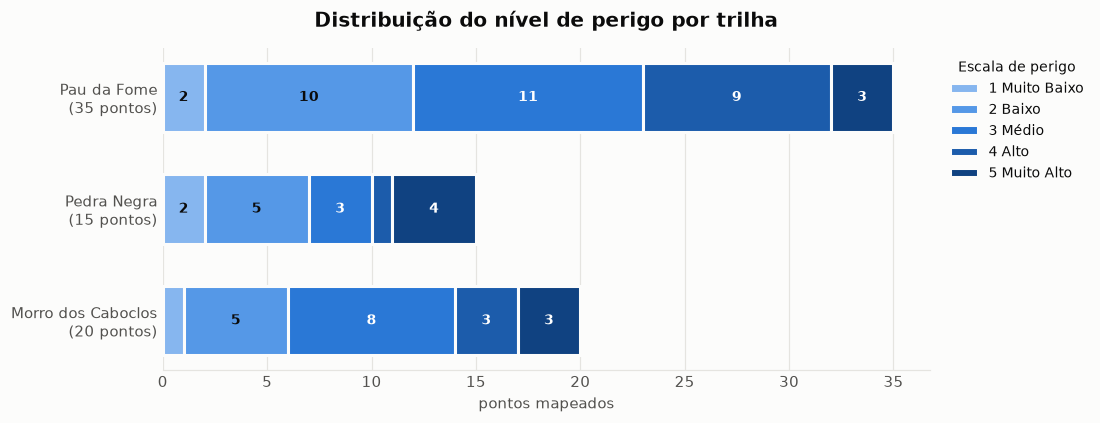

In [8]:
# =====================================================================
# CÉLULA 6 — Distribuição do perigo por trilha
# =====================================================================
ORDEM_TRILHAS = ["Pau da Fome", "Pedra Negra", "Morro dos Caboclos"]
tabela = pd.crosstab(pontos.trilha, pontos.perigo).reindex(ORDEM_TRILHAS)

# o total entra no rótulo do eixo: sem isso, a trilha maior parece pior
# só por ser maior
rotulos = [f"{t}\n({tabela.loc[t].sum()} pontos)" for t in tabela.index]

fig, ax = plt.subplots(figsize=(9, 3.8))
esquerda = pd.Series(0, index=tabela.index)

for cor, nivel in zip(RAMPA_PERIGO, tabela.columns):
    largura = tabela[nivel]
    ax.barh(rotulos, largura, left=esquerda, height=0.62, color=cor,
            edgecolor=SUPERFICIE, linewidth=2, zorder=3, label=nivel)
    for y, (x, v) in enumerate(zip(esquerda, largura)):
        if v >= 2:                       # rotula só onde o texto cabe
            ax.text(x + v/2, y, str(v), ha="center", va="center",
                    color="#ffffff" if cor in RAMPA_PERIGO[2:] else TINTA,
                    fontsize=9, fontweight="bold", zorder=4)
    esquerda += largura

ax.set_title("Distribuição do nível de perigo por trilha")
ax.set_xlabel("pontos mapeados")
ax.invert_yaxis()
limpar(ax)
ax.legend(title="Escala de perigo", bbox_to_anchor=(1.01, 1), loc="upper left",
          frameon=False, title_fontsize=9, fontsize=9)
salvar(fig, "01_perigo_por_trilha.png")


salvo: 02_tipos_de_processo.png


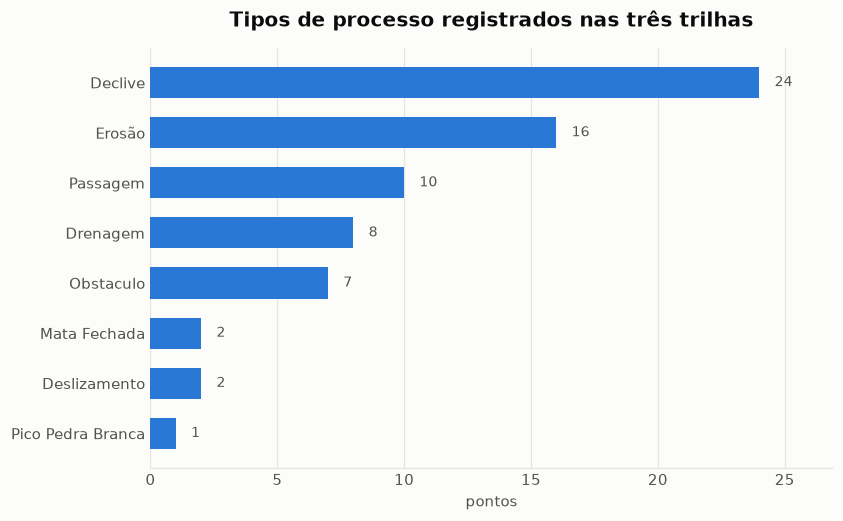

In [9]:
# =====================================================================
# CÉLULA 7 — Frequência dos tipos de processo
# =====================================================================
contagem = pontos.tipo.value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 0.42 * len(contagem) + 1.6))
ax.barh(contagem.index, contagem.values, height=0.62,
        color=SERIE_UNICA, zorder=3)
for y, v in enumerate(contagem.values):
    ax.text(v + 0.6, y, str(v), va="center", color=TINTA_FRACA, fontsize=9)

ax.set_title("Tipos de processo registrados nas três trilhas")
ax.set_xlabel("pontos")
ax.set_xlim(0, contagem.max() * 1.12)
limpar(ax)
salvar(fig, "02_tipos_de_processo.png")


salvo: 03_declividade_x_perigo.png


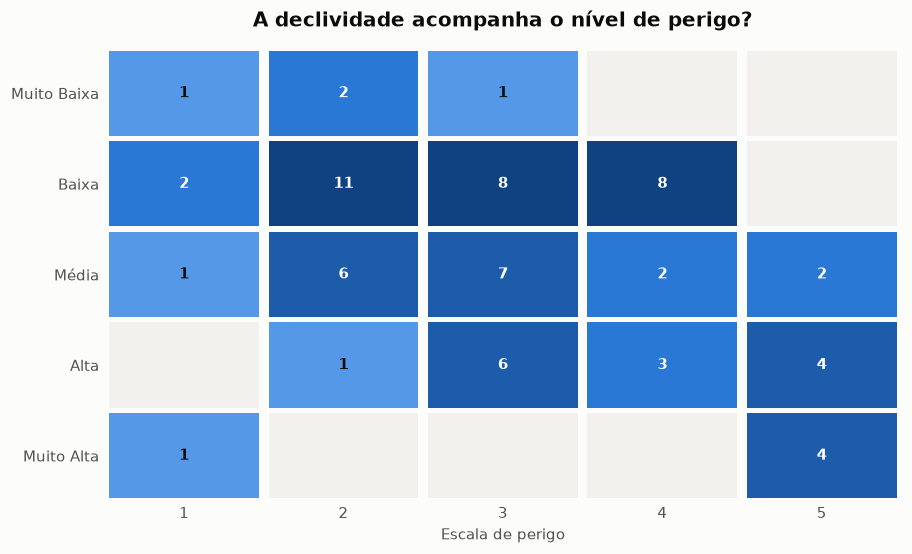

In [10]:
# =====================================================================
# CÉLULA 8 — Mapa de calor reutilizável
# =====================================================================
def mapa_de_calor(tabela, titulo, nome_arquivo,
                  rotulo_x="Escala de perigo", nota=None):
    """Tabela de contingência como grade de células rotuladas.

    Linhas e colunas inteiramente zeradas são descartadas: categorias
    declaradas mas sem ocorrência deixariam faixas vazias no gráfico.
    """
    tabela = tabela.loc[tabela.sum(axis=1) > 0, tabela.sum(axis=0) > 0]
    maximo = tabela.values.max() or 1

    fig, ax = plt.subplots(figsize=(1.15*len(tabela.columns) + 3.6,
                                    0.55*len(tabela.index) + 2.6))
    for i, linha in enumerate(tabela.index):
        for j, coluna in enumerate(tabela.columns):
            v = int(tabela.loc[linha, coluna])
            if v == 0:
                ax.add_patch(plt.Rectangle((j + 0.03, i + 0.03), 0.94, 0.94,
                                           facecolor=VAZIO, edgecolor="none"))
                continue
            # raiz quadrada: sem ela, um valor dominante empurra todo o
            # resto para o tom mais claro e a cor deixa de informar
            intensidade = (v / maximo) ** 0.5
            passo = min(int(intensidade * len(RAMPA_PERIGO)), len(RAMPA_PERIGO) - 1)
            ax.add_patch(plt.Rectangle((j + 0.03, i + 0.03), 0.94, 0.94,
                                       facecolor=RAMPA_PERIGO[passo],
                                       edgecolor="none"))
            ax.text(j + 0.5, i + 0.5, str(v), ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="#ffffff" if passo >= 2 else TINTA)

    ax.set_xlim(0, len(tabela.columns))
    ax.set_ylim(len(tabela.index), 0)
    ax.set_xticks([j + 0.5 for j in range(len(tabela.columns))])
    ax.set_xticklabels(tabela.columns)
    ax.set_yticks([i + 0.5 for i in range(len(tabela.index))])
    ax.set_yticklabels(tabela.index)
    ax.set_title(titulo)
    ax.set_xlabel(rotulo_x)
    if nota:
        ax.annotate(nota, xy=(0, -0.16), xycoords="axes fraction",
                    fontsize=9, color=TINTA_FRACA)
    for lado in ax.spines.values():
        lado.set_visible(False)
    ax.tick_params(length=0)
    salvar(fig, nome_arquivo)


mapa_de_calor(
    pd.crosstab(pontos.declividade, pontos.escala_perigo),
    "A declividade acompanha o nível de perigo?",
    "03_declividade_x_perigo.png",
    rotulo_x="Escala de perigo")


salvo: 04_solo_x_perigo.png
salvo: 05_erosao_x_declividade.png


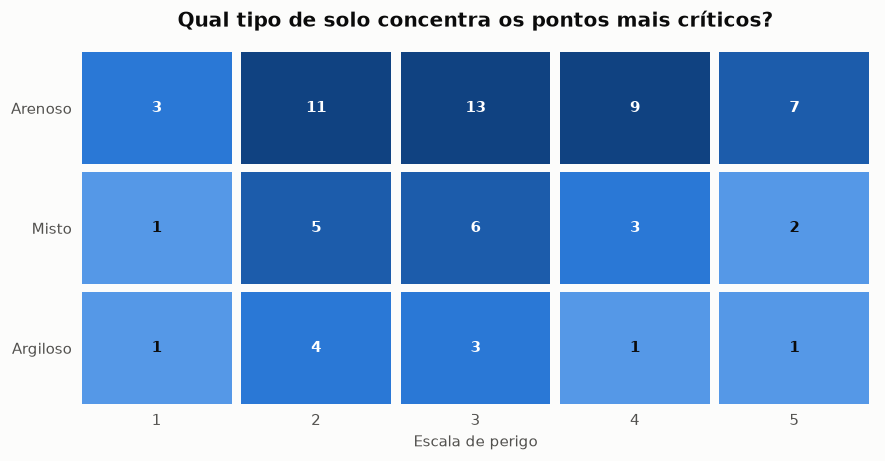

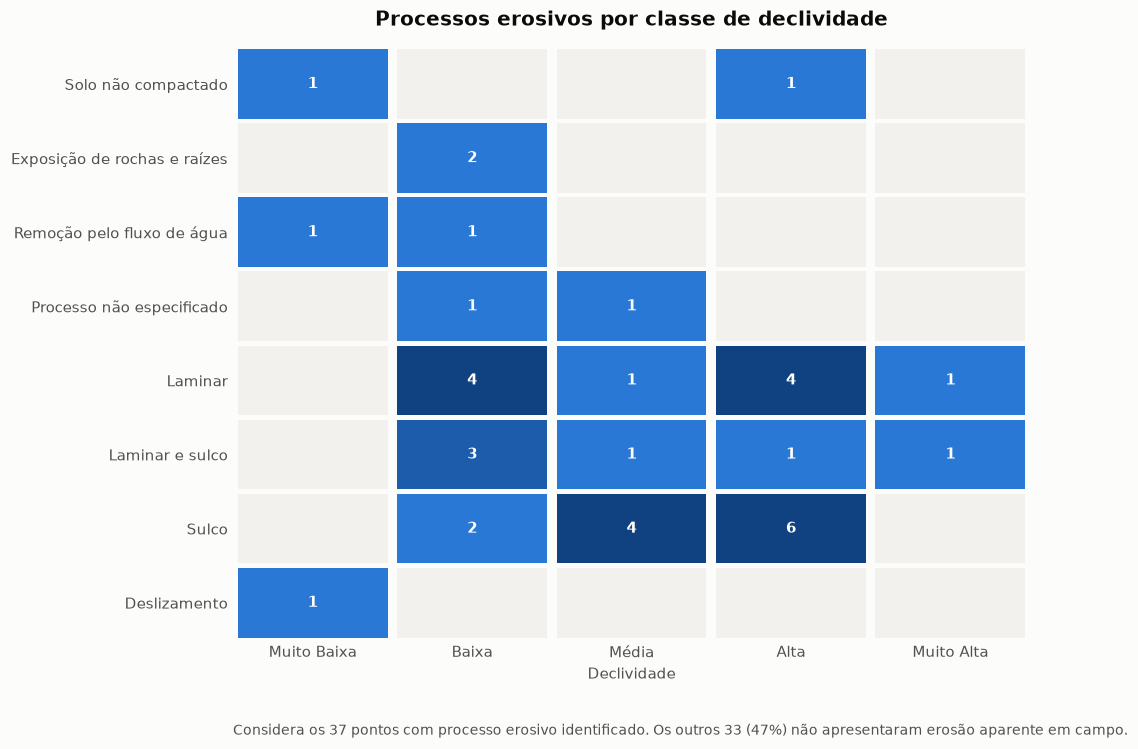

In [11]:
# =====================================================================
# CÉLULA 9 — Solo x perigo e erosão x declividade
# =====================================================================
mapa_de_calor(
    pd.crosstab(pontos.familia_solo, pontos.escala_perigo),
    "Qual tipo de solo concentra os pontos mais críticos?",
    "04_solo_x_perigo.png")

# A classe "Sem erosão observada" reúne 33 dos 70 pontos. Mantida na
# grade, ela domina a escala de cor e some com o contraste entre os
# processos, que é o que a pergunta investiga. Sai do gráfico e entra
# como nota.
com_erosao = pontos[pontos.classe_erosao != "Sem erosão observada"]
sem_erosao = len(pontos) - len(com_erosao)

mapa_de_calor(
    pd.crosstab(com_erosao.classe_erosao, com_erosao.declividade),
    "Processos erosivos por classe de declividade",
    "05_erosao_x_declividade.png",
    rotulo_x="Declividade",
    nota=f"Considera os {len(com_erosao)} pontos com processo erosivo "
         f"identificado. Os outros {sem_erosao} ({100*sem_erosao/len(pontos):.0f}%) "
         f"não apresentaram erosão aparente em campo.")


salvo: 06_riscos_x_perigo.png
salvo: 07_origem_do_perigo.png
=== Origem do perigo ===
                                pontos  perigo_medio  criticos  pct_criticos
origem_perigo                                                               
Nenhum dos dois                     21          2.05         1           4.8
Só declividade alta                  6          2.67         1          16.7
Só obstáculos                       30          3.23        11          36.7
Declividade alta\n+ obstáculos      13          4.38        10          76.9 

=== Perigo por quantidade de riscos acumulados no mesmo ponto ===
          pontos  perigo_medio  criticos
n_riscos                                
0             27          2.19         2
1             26          3.38        10
2             13          4.00         9
3              4          3.50         2


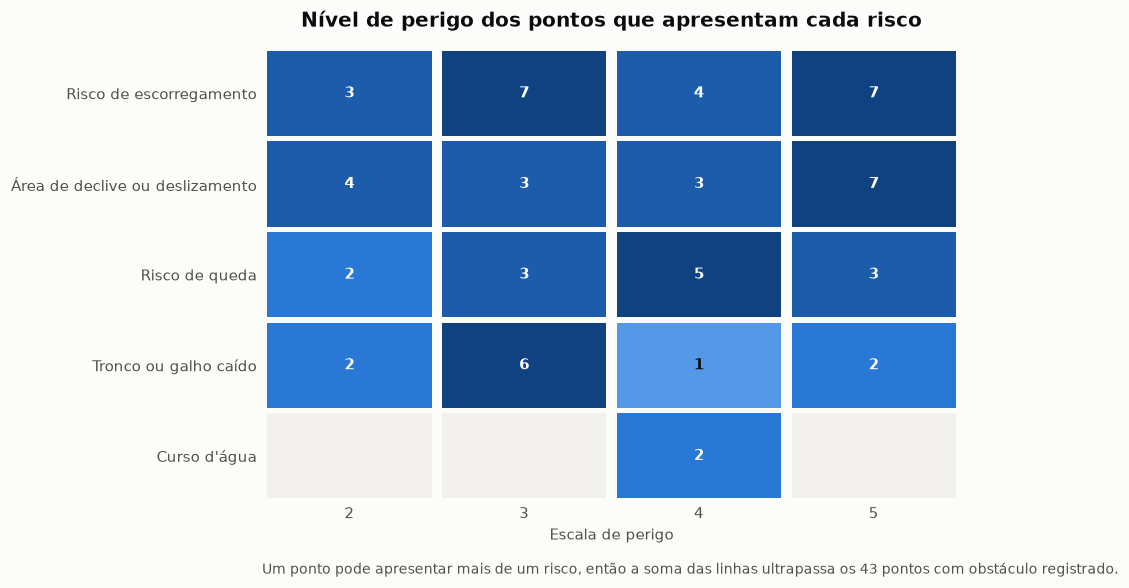

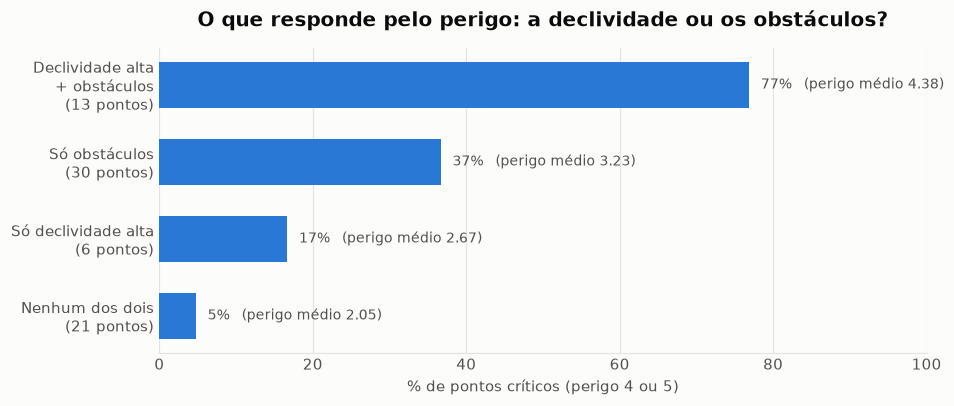

In [12]:
# =====================================================================
# CÉLULA 9B — Obstáculos e riscos x perigo
# =====================================================================
# O nível de perigo foi atribuído em campo ora pela declividade, ora
# pelos obstáculos presentes. Esta célula separa as duas origens.

# --- 1. Marcadores de risco a partir do texto ------------------------
# Um ponto pode ter vários riscos ao mesmo tempo ("solo escorregadio,
# risco de queda"), então cada risco é uma coluna verdadeiro/falso
# independente — não uma categoria única.
RISCOS = {
    "risco_queda":          r"risco de queda|alto risco de queda",
    "risco_escorregamento": r"ri+sco de escorregamento|escorregadio",
    "tronco_galho":         r"tronco|galho|cip[óo]",
    "area_declive":         r"declive|declividade|deslizamento",
    "curso_dagua":          r"\brio\b",
}
NOME_RISCO = {
    "risco_escorregamento": "Risco de escorregamento",
    "area_declive":         "Área de declive ou deslizamento",
    "risco_queda":          "Risco de queda",
    "tronco_galho":         "Tronco ou galho caído",
    "curso_dagua":          "Curso d'água",
}
for nome, padrao in RISCOS.items():
    pontos[nome] = pontos["obstaculos_riscos"].str.contains(
        padrao, case=False, regex=True)

pontos["n_riscos"] = pontos[list(RISCOS)].sum(axis=1)

# --- 2. Gráfico 6: cada risco x escala de perigo ---------------------
matriz = pd.DataFrame({
    NOME_RISCO[n]: pontos.loc[pontos[n], "escala_perigo"].value_counts()
    for n in RISCOS
}).T.reindex(columns=[1, 2, 3, 4, 5], fill_value=0).fillna(0).astype(int)
matriz = matriz.loc[matriz.sum(axis=1).sort_values(ascending=False).index]

mapa_de_calor(
    matriz,
    "Nível de perigo dos pontos que apresentam cada risco",
    "06_riscos_x_perigo.png",
    rotulo_x="Escala de perigo",
    nota="Um ponto pode apresentar mais de um risco, então a soma das "
         "linhas ultrapassa os 43 pontos com obstáculo registrado.")

# --- 3. Gráfico 7: o perigo veio da declividade ou do obstáculo? -----
pontos["decliv_alta"] = pontos["declividade"].isin(["Alta", "Muito Alta"])
pontos["tem_obstaculo"] = pontos["obstaculos_riscos"] != ""

def origem_do_perigo(linha):
    if linha.decliv_alta and linha.tem_obstaculo:
        return "Declividade alta\n+ obstáculos"
    if linha.decliv_alta:
        return "Só declividade alta"
    if linha.tem_obstaculo:
        return "Só obstáculos"
    return "Nenhum dos dois"

pontos["origem_perigo"] = pontos.apply(origem_do_perigo, axis=1)

origem = pontos.groupby("origem_perigo").agg(
    pontos_=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum"),
)
origem["pct_criticos"] = (100 * origem.criticos / origem.pontos_).round(1)
origem["perigo_medio"] = origem.perigo_medio.round(2)
origem = origem.sort_values("pct_criticos")

fig, ax = plt.subplots(figsize=(9, 3.6))
rotulos = [f"{i}\n({int(r.pontos_)} pontos)" for i, r in origem.iterrows()]
ax.barh(rotulos, origem.pct_criticos, height=0.6, color=SERIE_UNICA, zorder=3)
for y, (pct, media) in enumerate(zip(origem.pct_criticos, origem.perigo_medio)):
    ax.text(pct + 1.5, y, f"{pct:.0f}%   (perigo médio {media})",
            va="center", color=TINTA_FRACA, fontsize=9)

ax.set_title("O que responde pelo perigo: a declividade ou os obstáculos?")
ax.set_xlabel("% de pontos críticos (perigo 4 ou 5)")
ax.set_xlim(0, 100)
limpar(ax)
salvar(fig, "07_origem_do_perigo.png")

# --- 4. Tabelas ------------------------------------------------------
origem.rename(columns={"pontos_": "pontos"}).to_csv(
    SAIDA_CSV / "origem_do_perigo.csv", index_label="origem",
    encoding="utf-8-sig")
matriz.to_csv(SAIDA_CSV / "riscos_x_perigo.csv", index_label="risco",
              encoding="utf-8-sig")

print("=== Origem do perigo ===")
print(origem.rename(columns={"pontos_": "pontos"}).to_string(), "\n")
print("=== Perigo por quantidade de riscos acumulados no mesmo ponto ===")
print(pontos.groupby("n_riscos").agg(
    pontos=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum")).round(2).to_string())


salvo: 08_erosao_x_perigo.png
=== Perigo por severidade do processo erosivo ===
                            pontos  perigo_medio  criticos  pct_criticos
grupo_erosao                                                            
Sem erosão observada            33          3.00        13          39.4
Erosão laminar                  10          3.20         4          40.0
Laminar evoluindo p/ sulco       6          2.83         1          16.7
Erosão em sulco                 12          3.00         2          16.7
Outros processos                 9          3.22         3          33.3 

=== Com erosão x sem erosão ===
                         pontos  perigo_medio  criticos  pct_criticos
Sem erosão observada         33          3.00        13          39.4
Com erosão identificada      37          3.08        10          27.0


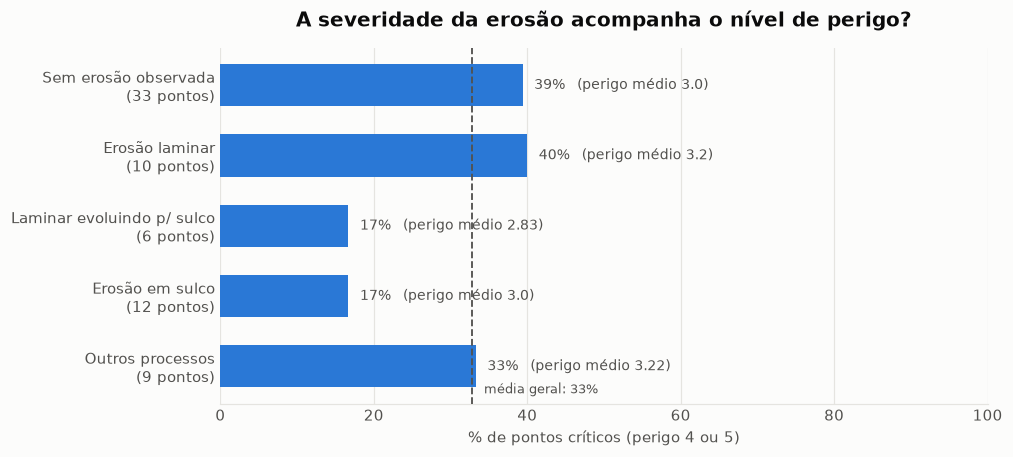

In [13]:
# =====================================================================
# CÉLULA 9C — Sinais de erosão x perigo
# =====================================================================
# O estágio erosivo consta como um dos critérios da escala de perigo.
# Esta célula verifica se ele de fato discrimina.

# --- 1. Agrupamento por severidade -----------------------------------
# As nove classes da Célula 3 são detalhadas demais para cruzar: cinco
# delas têm 1 ou 2 pontos. Agrupadas por severidade do processo, com
# os casos raros reunidos em "Outros processos".
SEVERIDADE = {
    "Sem erosão observada":         "Sem erosão observada",
    "Laminar":                      "Erosão laminar",
    "Laminar e sulco":              "Laminar evoluindo p/ sulco",
    "Sulco":                        "Erosão em sulco",
    "Solo não compactado":          "Outros processos",
    "Exposição de rochas e raízes": "Outros processos",
    "Remoção pelo fluxo de água":   "Outros processos",
    "Processo não especificado":    "Outros processos",
    "Deslizamento":                 "Outros processos",
}
ORDEM_SEVERIDADE = ["Sem erosão observada", "Erosão laminar",
                    "Laminar evoluindo p/ sulco", "Erosão em sulco",
                    "Outros processos"]

pontos["grupo_erosao"] = pd.Categorical(
    pontos["classe_erosao"].map(SEVERIDADE),
    categories=ORDEM_SEVERIDADE, ordered=True)

# --- 2. Gráfico 8: severidade da erosão x perigo ---------------------
erosao = pontos.groupby("grupo_erosao", observed=True).agg(
    pontos_=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum"),
)
erosao["pct_criticos"] = (100 * erosao.criticos / erosao.pontos_).round(1)
erosao["perigo_medio"] = erosao.perigo_medio.round(2)

media_geral = 100 * pontos.critico.sum() / len(pontos)

fig, ax = plt.subplots(figsize=(9, 4.2))
rotulos = [f"{i}\n({int(r.pontos_)} pontos)" for i, r in erosao.iterrows()]
ax.barh(rotulos, erosao.pct_criticos, height=0.6, color=SERIE_UNICA, zorder=3)
for y, (pct, media) in enumerate(zip(erosao.pct_criticos, erosao.perigo_medio)):
    ax.text(pct + 1.5, y, f"{pct:.0f}%   (perigo médio {media})",
            va="center", color=TINTA_FRACA, fontsize=9)

# linha de referência: se a erosão não pesasse, todas as barras
# ficariam em torno da média geral
ax.axvline(media_geral, color=TINTA_FRACA, linestyle="--", linewidth=1.2,
           zorder=4)
ax.annotate(f"média geral: {media_geral:.0f}%",
            xy=(media_geral + 1.5, 0.02), xycoords=("data", "axes fraction"),
            fontsize=8.5, color=TINTA_FRACA, va="bottom")

ax.set_title("A severidade da erosão acompanha o nível de perigo?")
ax.set_xlabel("% de pontos críticos (perigo 4 ou 5)")
ax.set_xlim(0, 100)
ax.invert_yaxis()
limpar(ax)
salvar(fig, "08_erosao_x_perigo.png")

# --- 3. Comparação agregada ------------------------------------------
pontos["tem_erosao"] = pontos["classe_erosao"] != "Sem erosão observada"
agregado = pontos.groupby("tem_erosao").agg(
    pontos_=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum"),
).round(2)
agregado.index = ["Sem erosão observada", "Com erosão identificada"]
agregado["pct_criticos"] = (100 * agregado.criticos / agregado.pontos_).round(1)

erosao.rename(columns={"pontos_": "pontos"}).to_csv(
    SAIDA_CSV / "erosao_severidade_x_perigo.csv", index_label="grupo_erosao",
    encoding="utf-8-sig")

print("=== Perigo por severidade do processo erosivo ===")
print(erosao.rename(columns={"pontos_": "pontos"}).to_string(), "\n")
print("=== Com erosão x sem erosão ===")
print(agregado.rename(columns={"pontos_": "pontos"}).to_string())


In [14]:
# =====================================================================
# CÉLULA 10 — Exportação
# =====================================================================

# Confere se as células anteriores rodaram: sem as colunas derivadas,
# a exportação sairia incompleta e sem avisar.
DERIVADAS = {
    "Célula 3":  ["trilha", "perigo", "critico", "familia_solo", "classe_erosao"],
    "Célula 9b": ["n_riscos", "origem_perigo", "risco_queda",
                  "risco_escorregamento", "tronco_galho", "area_declive",
                  "curso_dagua"],
    "Célula 9c": ["grupo_erosao", "tem_erosao"],
}
for celula, colunas in DERIVADAS.items():
    faltando = [c for c in colunas if c not in pontos.columns]
    if faltando:
        print(f"ATENÇÃO — rode a {celula} antes desta. Faltam: {faltando}\n")

tabelas = {
    "perigo_por_trilha":       pd.crosstab(pontos.trilha, pontos.perigo),
    "tipos_por_trilha":        pd.crosstab(pontos.tipo, pontos.trilha),
    "declividade_x_perigo":    pd.crosstab(pontos.declividade, pontos.escala_perigo),
    "solo_x_perigo":           pd.crosstab(pontos.familia_solo, pontos.escala_perigo),
    "solo_detalhado_x_perigo": pd.crosstab(pontos.solo, pontos.escala_perigo),
    "erosao_x_declividade":    pd.crosstab(pontos.classe_erosao, pontos.declividade),
    "erosao_x_perigo":         pd.crosstab(pontos.classe_erosao, pontos.escala_perigo),
    "origem_x_trilha":         pd.crosstab(pontos.origem_perigo, pontos.trilha),
    "erosao_x_origem":         pd.crosstab(pontos.grupo_erosao, pontos.origem_perigo),
}
for nome, tabela in tabelas.items():
    tabela.to_csv(SAIDA_CSV / f"{nome}.csv", encoding="utf-8-sig")

# Base completa para o Power BI, com as colunas derivadas nas Células 3, 9b e 9c.
# `condicoes_trilha` fica de fora: 70 descrições únicas de ~112 caracteres
# não alimentam nenhum visual.
base = pontos.drop(columns=["condicoes_trilha"])
base.to_csv(SAIDA_CSV / "pontos_completo.csv", index=False, encoding="utf-8-sig")

print(f"Imagens geradas ({len(list(SAIDA_IMG.glob('*.png')))}):")
for a in sorted(SAIDA_IMG.glob("*.png")):
    print(f"   {a.name:<34} {a.stat().st_size//1024:>4} KB")

print(f"\nTabelas geradas ({len(list(SAIDA_CSV.glob('*.csv')))}):")
for a in sorted(SAIDA_CSV.glob("*.csv")):
    print(f"   {a.name}")

print(f"\npontos_completo.csv: {len(base)} linhas x {len(base.columns)} colunas")
print("colunas:", ", ".join(base.columns))


Imagens geradas (8):
   01_perigo_por_trilha.png             73 KB
   02_tipos_de_processo.png             52 KB
   03_declividade_x_perigo.png          43 KB
   04_solo_x_perigo.png                 36 KB
   05_erosao_x_declividade.png          95 KB
   06_riscos_x_perigo.png               69 KB
   07_origem_do_perigo.png              82 KB
   08_erosao_x_perigo.png              102 KB

Tabelas geradas (14):
   declividade_x_perigo.csv
   erosao_severidade_x_perigo.csv
   erosao_x_declividade.csv
   erosao_x_origem.csv
   erosao_x_perigo.csv
   origem_do_perigo.csv
   origem_x_trilha.csv
   perigo_por_trilha.csv
   pontos_completo.csv
   riscos_x_perigo.csv
   sintese_por_trilha.csv
   solo_detalhado_x_perigo.csv
   solo_x_perigo.csv
   tipos_por_trilha.csv

pontos_completo.csv: 70 linhas x 25 colunas
colunas: id_ponto, id_trilha, tipo, declividade, solo, sinais_erosao, obstaculos_riscos, nivel_perigo, escala_perigo, trilha, perigo, critico, familia_solo, classe_erosao, risco_queda, ri